In [1]:
import pandas as pd
from pathlib import Path

# Relative paths from notebooks/playground/ to your data and visualization folders
data_path = Path("../../data/train.csv")
output_path = Path("../../visualization/output_report.txt")

# Load dataset
df = pd.read_csv(data_path)
df.head()

,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call...","[""Function calling is the process of invoking ...","[""Function calling is the process of invoking ...",0,0,1
3,96401,llama-2-13b-chat,mistral-7b-instruct,"[""How can I create a test set for a very rare ...","[""Creating a test set for a very rare category...","[""When building a classifier for a very rare c...",1,0,0
4,198779,koala-13b,gpt-3.5-turbo-0314,"[""What is the best way to travel from Tel-Aviv...","[""The best way to travel from Tel Aviv to Jeru...","[""The best way to travel from Tel-Aviv to Jeru...",0,1,0


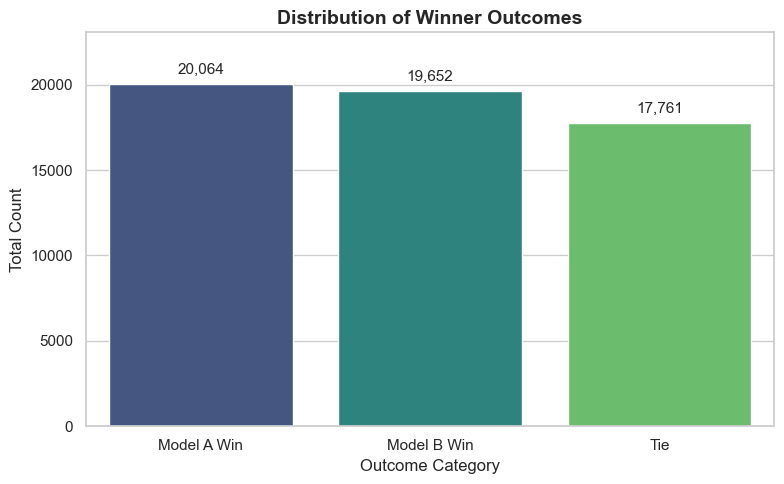

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Load dataset
data_path = Path("../../data/train.csv")
df = pd.read_csv(data_path)

# Calculate totals for each winner column
winner_cols = ["winner_model_a", "winner_model_b", "winner_tie"]
win_counts = df[winner_cols].sum()

# Create the figure
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=win_counts.index,
    y=win_counts.values,
    hue=win_counts.index,
    palette="viridis",
    legend=False,
)

# Annotate each bar with its exact count
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{int(height):,}",
        (p.get_x() + p.get_width() / 2.0, height),
        ha="center",
        va="bottom",
        fontsize=11,
        xytext=(0, 5),
        textcoords="offset points",
    )

# Chart labels and formatting
plt.title("Distribution of Winner Outcomes", fontsize=14, fontweight="bold")
plt.xlabel("Outcome Category", fontsize=12)
plt.ylabel("Total Count", fontsize=12)
plt.ylim(0, max(win_counts.values) * 1.15)  # Add padding above highest bar
plt.xticks(
    ticks=range(len(winner_cols)),
    labels=["Model A Win", "Model B Win", "Tie"],
)

plt.tight_layout()
plt.show()

In [3]:
print(df.count())

id                57477
model_a           57477
model_b           57477
prompt            57477
response_a        57477
response_b        57477
winner_model_a    57477
winner_model_b    57477
winner_tie        57477
dtype: int64


In [4]:
target_cols = ['winner_model_a', 'winner_model_b', 'winner_tie']

# Counts and percentages for targets
print(df[target_cols].sum())
print("\nPercentage distribution:")
print(df[target_cols].mean() * 100)

winner_model_a    20064
winner_model_b    19652
winner_tie        17761
dtype: int64

Percentage distribution:
winner_model_a    34.907876
winner_model_b    34.191068
winner_tie        30.901056
dtype: float64


In [5]:
# Most frequent models evaluated
print("Top Model A entries:")
print(df['model_a'].value_counts().head(10))

print("\nTop Model B entries:")
print(df['model_b'].value_counts().head(10))

Top Model A entries:
model_a
gpt-4-1106-preview            3678
gpt-3.5-turbo-0613            3553
gpt-4-0613                    3099
claude-2.1                    2859
gpt-4-0314                    2087
claude-instant-1              2085
claude-1                      1955
vicuna-33b                    1843
mixtral-8x7b-instruct-v0.1    1741
mistral-medium                1706
Name: count, dtype: int64

Top Model B entries:
model_b
gpt-4-1106-preview            3709
gpt-3.5-turbo-0613            3530
gpt-4-0613                    3066
claude-2.1                    2724
claude-instant-1              2051
gpt-4-0314                    2035
claude-1                      2023
vicuna-33b                    1877
mixtral-8x7b-instruct-v0.1    1804
llama-2-70b-chat              1753
Name: count, dtype: int64


/var/folders/cz/kgxfppq91q52_bkcdbmh46q80000gn/T/ipykernel_67631/4183813477.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_a.values, y=top_a.index, ax=axes[0], palette="Blues_r")
/var/folders/cz/kgxfppq91q52_bkcdbmh46q80000gn/T/ipykernel_67631/4183813477.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_b.values, y=top_b.index, ax=axes[1], palette="Oranges_r")


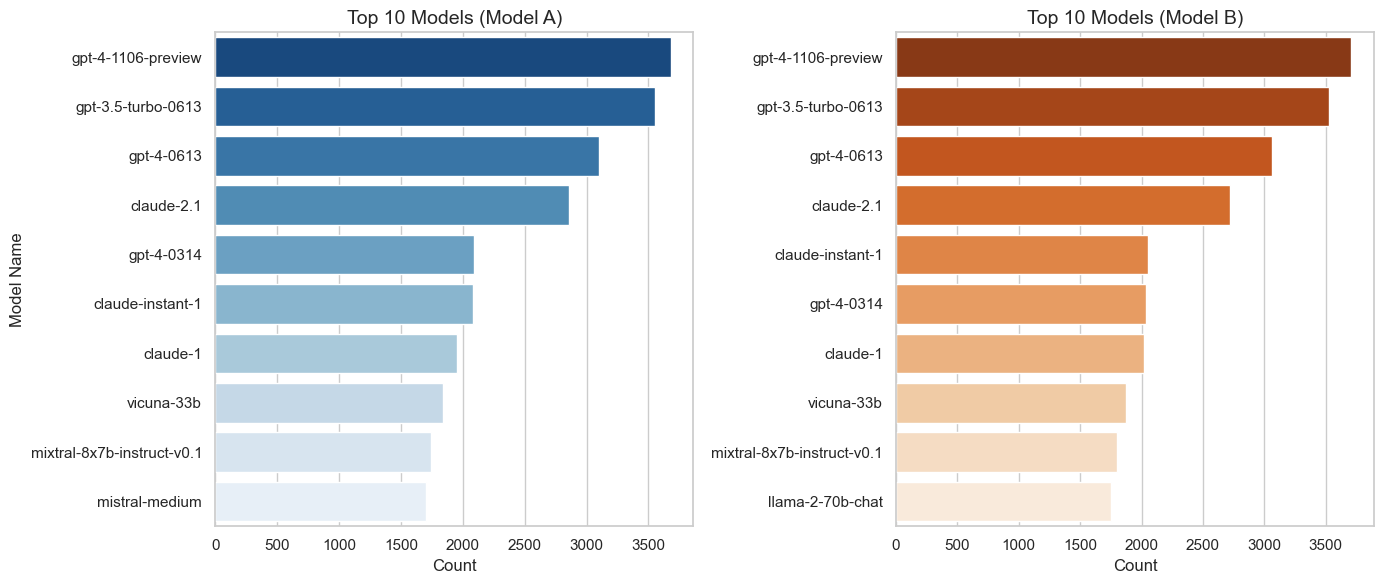

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set overall plot style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 Model A
top_a = df['model_a'].value_counts().head(10)
sns.barplot(x=top_a.values, y=top_a.index, ax=axes[0], palette="Blues_r")
axes[0].set_title("Top 10 Models (Model A)", fontsize=14)
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Model Name")

# Top 10 Model B
top_b = df['model_b'].value_counts().head(10)
sns.barplot(x=top_b.values, y=top_b.index, ax=axes[1], palette="Oranges_r")
axes[1].set_title("Top 10 Models (Model B)", fontsize=14)
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [6]:
text_cols = ['prompt', 'response_a', 'response_b']

# Calculate character and word lengths
for col in text_cols:
    df[f'{col}_len'] = df[col].astype(str).str.len()
    df[f'{col}_word_count'] = df[col].astype(str).apply(lambda x: len(x.split()))

# Summary statistics of length metrics
len_cols = [c for c in df.columns if '_len' in c or '_word_count' in c]
print(df[len_cols].describe())

         prompt_len  prompt_word_count  response_a_len  response_a_word_count  \
count  57477.000000       57477.000000    57477.000000           57477.000000   
mean     369.198584          54.006333     1377.818919             204.371070   
std     1073.341472         143.929514     1513.932333             218.697891   
min        7.000000           1.000000        4.000000               1.000000   
25%       52.000000           9.000000      408.000000              64.000000   
50%       96.000000          16.000000     1076.000000             162.000000   
75%      243.000000          40.000000     1862.000000             279.000000   
max    33056.000000        4719.000000    54058.000000            9021.000000   

       response_b_len  response_b_word_count  
count    57477.000000           57477.000000  
mean      1386.162169             205.177254  
std       1537.800488             220.905999  
min          4.000000               1.000000  
25%        413.000000              

In [7]:
# Average response length by winner
print("Avg Response A length when A wins:", df[df['winner_model_a'] == 1]['response_a_len'].mean())
print("Avg Response B length when B wins:", df[df['winner_model_b'] == 1]['response_b_len'].mean())

Avg Response A length when A wins: 1567.6192185007974
Avg Response B length when B wins: 1569.1136779971505


Top 10 Winning Models:
gpt-4-1106-preview            6100
gpt-3.5-turbo-0613            4598
gpt-4-0613                    4309
claude-2.1                    3317
gpt-4-0314                    3192
claude-1                      2933
claude-instant-1              2856
vicuna-33b                    2542
llama-2-70b-chat              2390
mixtral-8x7b-instruct-v0.1    2335
Name: count, dtype: int64


/var/folders/cz/kgxfppq91q52_bkcdbmh46q80000gn/T/ipykernel_67631/2829008964.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_wins.values, y=top_10_wins.index, palette="viridis")


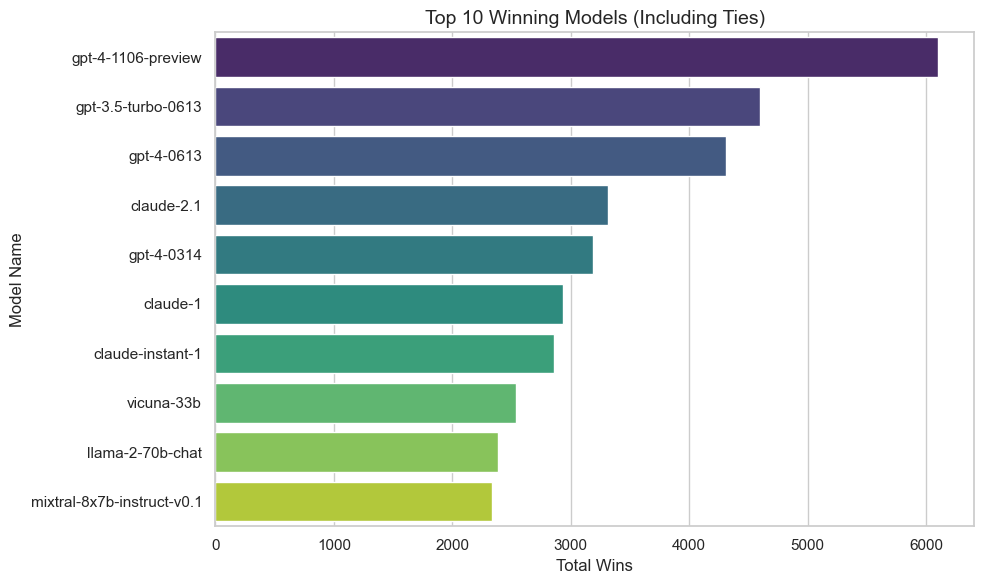

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter dataset into wins and ties
a_wins = df[df['winner_model_a'] == 1]['model_a']
b_wins = df[df['winner_model_b'] == 1]['model_b']

ties_a = df[df['winner_tie'] == 1]['model_a']
ties_b = df[df['winner_tie'] == 1]['model_b']

# 2. Combine all winning instances into a single Series
# (Ties give +1 win count to both model_a and model_b)
all_wins = pd.concat([a_wins, b_wins, ties_a, ties_b])

# 3. Get total win counts per model
win_counts = all_wins.value_counts()

print("Top 10 Winning Models:")
print(win_counts.head(10))

# 4. Plot the results
plt.figure(figsize=(10, 6))
top_10_wins = win_counts.head(10)

sns.barplot(x=top_10_wins.values, y=top_10_wins.index, palette="viridis")
plt.title("Top 10 Winning Models (Including Ties)", fontsize=14)
plt.xlabel("Total Wins")
plt.ylabel("Model Name")

plt.tight_layout()
plt.show()

In [10]:
import numpy as np

# Define conditions based on your columns
conditions = [
    df['winner_tie'] == 1,       # 0: Tie
    df['winner_model_a'] == 1,   # 1: Model A wins
    df['winner_model_b'] == 1    # 2: Model B wins
]

# Assign corresponding choices [0, 1, 2]
choices = [0, 1, 2]

# Create the target array y
y = np.select(conditions, choices, default=0)

In [11]:
# Assign as an integer column
df['target'] = np.select(conditions, choices, default=0).astype(int)

# Verify the outcome counts in the dataframe
print(df['target'].value_counts().sort_index())

target
0    17761
1    20064
2    19652
Name: count, dtype: int64


/var/folders/cz/kgxfppq91q52_bkcdbmh46q80000gn/T/ipykernel_67631/3085912091.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df['target'], palette='Blues_d')


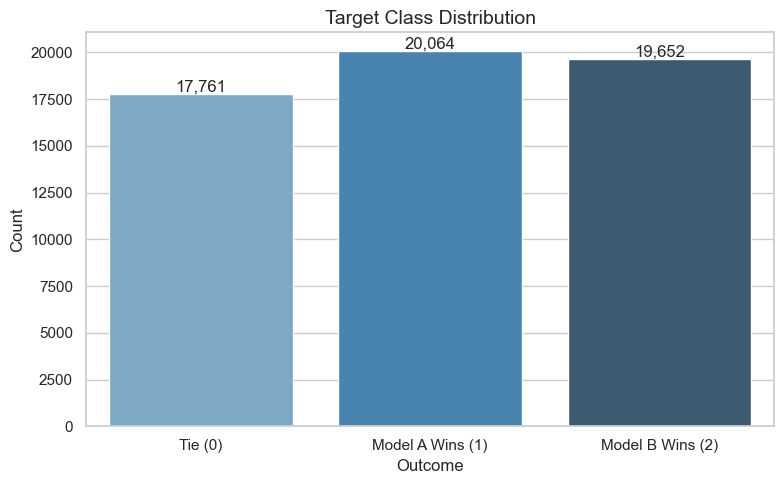

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot target distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(x=df['target'], palette='Blues_d')

# Add class names to x-axis ticks
plt.xticks(ticks=[0, 1, 2], labels=['Tie (0)', 'Model A Wins (1)', 'Model B Wins (2)'])
plt.title('Target Class Distribution', fontsize=14)
plt.xlabel('Outcome')
plt.ylabel('Count')

# Add values above bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# 1. Define feature columns and target
features = ['model_a', 'model_b']
X = df[features]
y = df['target']  # 0: Tie, 1: Model A Wins, 2: Model B Wins

# 2. Train-test split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Preprocessing: Convert model names into categorical dummy variables
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['model_a', 'model_b'])
    ]
)

# 4. Build a linear classification pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# 5. Train model
model.fit(X_train, y_train)

# 6. Evaluate model
y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)

print(f"Validation Accuracy: {accuracy_score(y_val, y_pred):.4f}\n")
print(classification_report(y_val, y_pred, target_names=['Tie (0)', 'Model A (1)', 'Model B (2)']))

Validation Accuracy: 0.4502

              precision    recall  f1-score   support

     Tie (0)       0.37      0.10      0.16      3552
 Model A (1)       0.46      0.60      0.52      4013
 Model B (2)       0.45      0.61      0.52      3931

    accuracy                           0.45     11496
   macro avg       0.43      0.44      0.40     11496
weighted avg       0.43      0.45      0.41     11496



In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import lightgbm as lgb

# 1. Define features and target
X = df[['model_a', 'model_b']].copy()
y = df['target']  # 0: Tie, 1: Model A Wins, 2: Model B Wins

# Convert string columns to categorical dtype for LightGBM
X['model_a'] = X['model_a'].astype('category')
X['model_b'] = X['model_b'].astype('category')

# 2. Train-Test Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Define LightGBM Multi-class Classifier
model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=3,
    n_estimators=100,
    learning_rate=0.05,
    random_state=42
)

# 4. Fit the model
model.fit(X_train, y_train)

# 5. Predict and Evaluate
y_pred = model.predict(X_val)

print(f"Validation Accuracy: {accuracy_score(y_val, y_pred):.4f}\n")
print(classification_report(y_val, y_pred, target_names=['Tie (0)', 'Model A (1)', 'Model B (2)']))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000260 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 128
[LightGBM] [Info] Number of data points in the train set: 45981, number of used features: 2
[LightGBM] [Info] Start training from score -1.174353
[LightGBM] [Info] Start training from score -1.052457
[LightGBM] [Info] Start training from score -1.073231
Validation Accuracy: 0.4435

              precision    recall  f1-score   support

     Tie (0)       0.36      0.20      0.25      3552
 Model A (1)       0.46      0.55      0.50      4013
 Model B (2)       0.46      0.55      0.50      3931

    accuracy                           0.44     11496
   macro avg       0.43      0.43      0.42     11496
weighted avg       0.43      0.44      0.43     11496



In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# 1. Prepare features and target
X = df[['model_a', 'model_b']]
y = df['target']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. One-Hot Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['model_a', 'model_b'])
    ]
)

# 3. XGBoost Pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        n_estimators=100,
        learning_rate=0.05,
        random_state=42
    ))
])

# 4. Train and Evaluate
model.fit(X_train, y_train)
y_pred = model.predict(X_val)

print(f"Validation Accuracy: {accuracy_score(y_val, y_pred):.4f}\n")
print(classification_report(y_val, y_pred, target_names=['Tie (0)', 'Model A (1)', 'Model B (2)']))

Validation Accuracy: 0.4356

              precision    recall  f1-score   support

     Tie (0)       0.36      0.10      0.15      3552
 Model A (1)       0.42      0.71      0.53      4013
 Model B (2)       0.48      0.46      0.47      3931

    accuracy                           0.44     11496
   macro avg       0.42      0.42      0.38     11496
weighted avg       0.42      0.44      0.39     11496



In [16]:
from sklearn.metrics import log_loss

# Extract target probability matrix (N, 3)
y_true_matrix = df[['winner_model_a', 'winner_model_b', 'winner_tie']].values

# Get predicted probabilities from your fitted model (e.g., Logistic Regression / LightGBM)
y_pred_probs = model.predict_proba(X_val)

# Compute Kaggle metric score
kaggle_score = log_loss(y_true_matrix, y_pred_probs)
print(f"Validation Log Loss: {kaggle_score:.5f}")

ValueError: Found input variables with inconsistent numbers of samples: [11496, 57477]

In [20]:
from sklearn.metrics import log_loss

# Get predicted probabilities for validation set
y_pred_probs = model.predict_proba(X_val)

# Compute Log Loss using y_val directly
kaggle_score = log_loss(y_val, y_pred_probs)
print(f"Validation Log Loss: {kaggle_score:.5f}")

Validation Log Loss: 1.04279
